<a href="https://colab.research.google.com/github/prs-016/Hot_Streaks_ECLIPSE/blob/main/HeatCheckAlgorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install statsmodels
!pip install seaborn
!pip install pbpstats
!pip install nba_on_court
!pip install xgboost scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle, Rectangle, Arc
from nba_api.stats.endpoints import shotchartdetail, leagueleaders
from scipy.interpolate import PchipInterpolator
import time

To run this: go to your drive and upload nba_shot_data.csv to home page!!!!

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/My Drive/nba_shot_data.csv'
df = pd.read_csv(file_path)
print(f"Successfully loaded {len(df)} shots from CSV!")

Successfully loaded 99960 shots from CSV!


The cell below will not run. Thats fine if you uploaded to google drive-> if you dont wnat to upload to google drive the cell above will not run in that case click on folders on left page(below the key icon and above the calculator type icon) and upload nba_shot_data.csv there

In [ ]:
"""
only in vscode for loading data, i uploaded the data here through a file
# ==========================================
# 1. DATA LOADING (2019-2024, TOP SCORERS)
# ==========================================
print("Fetching Top Scorers from 2019-2024...")

seasons = [
    '2019-20', '2020-21', '2021-22', '2022-23', '2023-24'
]

all_shots = []

# UPGRADED HEADERS: The ultimate disguise to bypass NBA's Akamai Bot Manager
custom_headers = {
    'Host': 'stats.nba.com',
    'Connection': 'keep-alive',
    'Accept': 'application/json, text/plain, */*',
    'x-nba-stats-token': 'true',
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
    'x-nba-stats-origin': 'stats',
    'Sec-Fetch-Site': 'same-site',
    'Sec-Fetch-Mode': 'cors',
    'Referer': 'https://www.nba.com/',
    'Origin': 'https://www.nba.com',
    'Accept-Language': 'en-US,en;q=0.9',
}

for season in seasons:
    print(f"\nProcessing Season: {season}")
    try:
        # Get Top 50 Scorers
        leaders = leagueleaders.LeagueLeaders(season=season, headers=custom_headers).get_data_frames()[0]
        top_ids = leaders.head(50)['PLAYER_ID'].tolist()

        # Fetch Top 15 players per season for speed
        for i, pid in enumerate(top_ids[:15]):
            success = False
            retries = 3

            for attempt in range(retries):
                try:
                    response = shotchartdetail.ShotChartDetail(
                        team_id=0,
                        player_id=pid,
                        season_nullable=season,
                        context_measure_simple='FGA',
                        timeout=15,
                        headers=custom_headers
                    )
                    player_df = response.get_data_frames()[0]
                    player_df['SEASON_ID'] = season
                    all_shots.append(player_df)

                    time.sleep(1.5) # Safe sleep time
                    success = True
                    print(f"  [{i+1}/15] Success for Player ID: {pid}")
                    break

                except Exception as e:
                    print(f"  [{i+1}/15] Timeout/Error for Player {pid} (Attempt {attempt+1}/{retries}). Resting 5s...")
                    time.sleep(5.0)

            if not success:
                print(f"  -> Skipping Player {pid} after {retries} failed attempts.")

    except Exception as e:
        print(f"Error fetching leaders for {season}: {e}")

if not all_shots:
    print("No data found. Stopping here.")
else:
    df = pd.concat(all_shots, ignore_index=True)
    print(f"\nTotal Shots Loaded: {len(df)}")

df.to_csv('nba_shot_data.csv', index=False)
print("Data successfully saved to CSV!")

"""

# Load the data we downloaded from VS Code
df = pd.read_csv('nba_shot_data.csv')
print(f"Successfully loaded {len(df)} shots from CSV!")

FileNotFoundError: [Errno 2] No such file or directory: 'nba_shot_data.csv'

In [ ]:
# ==========================================
# 2. DATA PREP
# ==========================================
df['X_feet'] = df['LOC_X'] / 10
df['Y_feet'] = df['LOC_Y'] / 10

# Filter: EXCLUDE shots within 15 feet
df = df[df['SHOT_DISTANCE'] > 15].copy()

# Calculate Absolute Game Time
def calculate_time_elapsed(row):
    period = row['PERIOD']
    min_left = row['MINUTES_REMAINING']
    sec_left = row['SECONDS_REMAINING']

    period_length = 720 if period <= 4 else 300
    seconds_left_in_period = (min_left * 60) + sec_left

    if period <= 4:
        start_time = (period - 1) * 720
    else:
        start_time = 2880 + (period - 5) * 300

    return start_time + (period_length - seconds_left_in_period)

df['game_seconds_elapsed'] = df.apply(calculate_time_elapsed, axis=1)

# Sort strictly
df = df.sort_values(by=['SEASON_ID', 'GAME_ID', 'PLAYER_ID', 'game_seconds_elapsed'])

# ==========================================
# 3. HEAT CHECK ALGORITHM
# ==========================================
print("Identifying Heat Checks...")

g = df.groupby(['SEASON_ID', 'GAME_ID', 'PLAYER_ID'])

df['prev_1_make'] = g['SHOT_MADE_FLAG'].shift(1)
df['prev_2_make'] = g['SHOT_MADE_FLAG'].shift(2)
df['prev_2_time'] = g['game_seconds_elapsed'].shift(2)

conditions = (
    (df['prev_1_make'] == 1) &
    (df['prev_2_make'] == 1) &
    ((df['game_seconds_elapsed'] - df['prev_2_time']) <= 180)
)

df['shot_type'] = np.where(conditions, 'Heat Check', 'Normal Shot')

heat_checks = df[df['shot_type'] == 'Heat Check'].copy()
regular_shots = df[df['shot_type'] == 'Normal Shot'].copy()

print(f"Found {len(heat_checks)} Heat Checks and {len(regular_shots)} Regular Shots.")

Identifying Heat Checks...
Found 1330 Heat Checks and 41535 Regular Shots.


Generating 3 Separate Graphs...


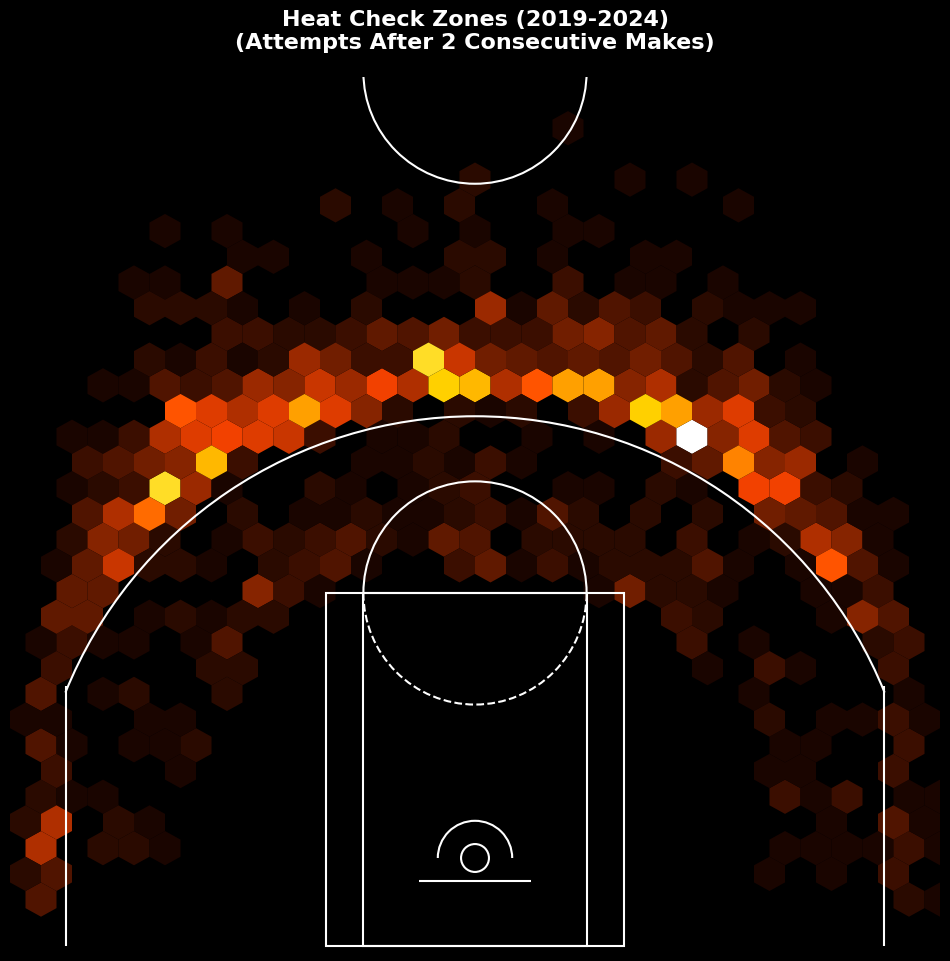

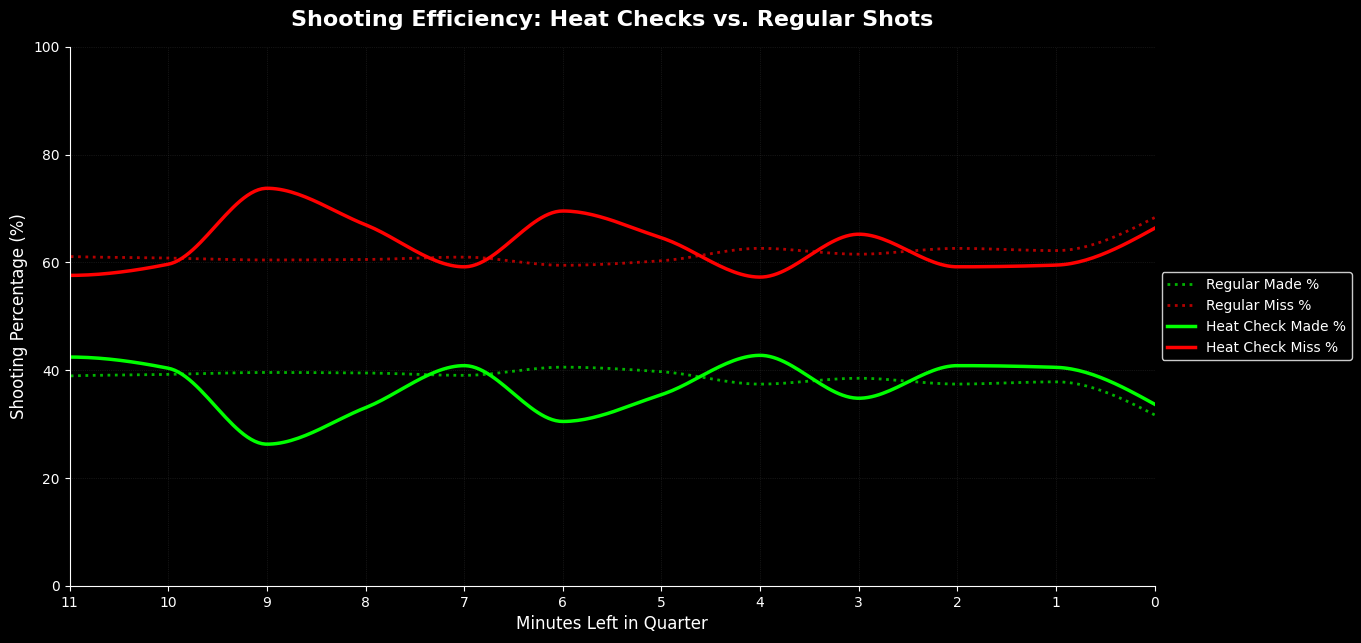

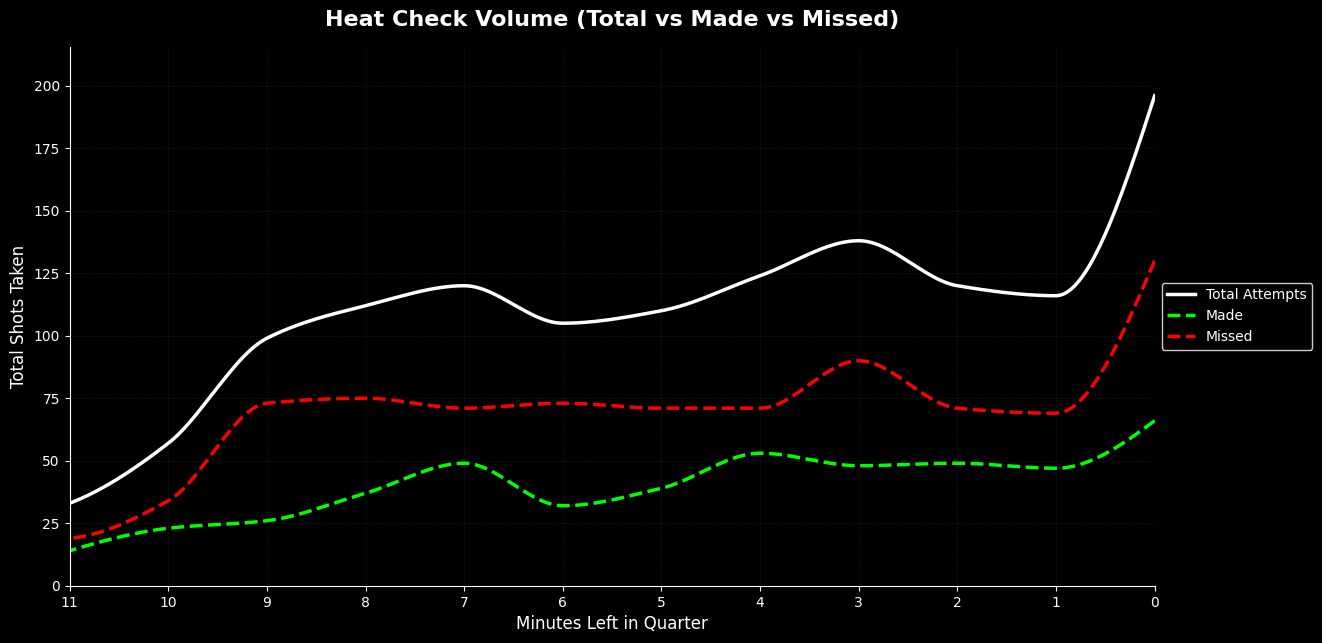

In [ ]:
# ==========================================
# 4. PLOTTING SETUP
# ==========================================
print("Generating 3 Separate Graphs...")

# Helper: Smooth Lines
def plot_smooth_line(ax, x_data, y_data, color, label, linestyle='-', linewidth=2.5, alpha=1.0):
    if len(x_data) < 2: return
    x_new = np.linspace(x_data.min(), x_data.max(), 300)
    interpolator = PchipInterpolator(x_data, y_data)
    y_smooth = interpolator(x_new)
    y_smooth = np.maximum(y_smooth, 0)
    ax.plot(x_new, y_smooth, color=color, linewidth=linewidth, label=label, linestyle=linestyle, alpha=alpha)

# Helper: Draw Court
def draw_nba_court(ax=None, color='white', lw=1.5):
    if ax is None: ax = plt.gca()
    ax.add_patch(Circle((0, 0), radius=0.75, linewidth=lw, color=color, fill=False))
    ax.add_patch(Rectangle((-3, -1.25), 6, 0, linewidth=lw, color=color))
    ax.add_patch(Rectangle((-8, -4.75), 16, 19, linewidth=lw, color=color, fill=False))
    ax.add_patch(Rectangle((-6, -4.75), 12, 19, linewidth=lw, color=color, fill=False))
    ax.add_patch(Arc((0, 14.25), 12, 12, theta1=0, theta2=180, linewidth=lw, color=color, fill=False))
    ax.add_patch(Arc((0, 14.25), 12, 12, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed'))
    ax.add_patch(Arc((0, 0), 4, 4, theta1=0, theta2=180, linewidth=lw, color=color))
    ax.add_patch(Rectangle((-22, -4.75), 0, 14, linewidth=lw, color=color))
    ax.add_patch(Rectangle((22, -4.75), 0, 14, linewidth=lw, color=color))
    ax.add_patch(Arc((0, 0), 47.5, 47.5, theta1=22, theta2=158, linewidth=lw, color=color))
    ax.add_patch(Arc((0, 42.25), 12, 12, theta1=180, theta2=360, linewidth=lw, color=color))
    return ax

# Helper: Common Dark Mode Styling
def style_dark_mode(ax):
    ax.set_facecolor('black')
    ax.grid(axis='both', color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
    ax.tick_params(axis='both', colors='white')
    for spine in ax.spines.values(): spine.set_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ==========================================
# FIGURE 1: HEXBIN MAP
# ==========================================
plt.figure(1, figsize=(12, 12), facecolor='black')
ax1 = plt.gca()
ax1.set_facecolor('black')

colors = ['#1a0500', '#802200', '#FF4500', '#FFD700', '#FFFFFF']
cmap = mcolors.LinearSegmentedColormap.from_list("black_to_neon", colors, N=100)

ax1.hexbin(
    heat_checks['X_feet'],
    heat_checks['Y_feet'],
    gridsize=30,
    cmap=cmap,
    mincnt=1,
    extent=(-25, 25, -5, 42),
    edgecolors='none',
    zorder=1
)

draw_nba_court(ax1, color='white', lw=1.5)
ax1.set_aspect('equal')
ax1.set_xlim(-25, 25)
ax1.set_ylim(-5, 42)
ax1.axis('off')
ax1.set_title("Heat Check Zones (2019-2024)\n(Attempts After 2 Consecutive Makes)",
              color='white', fontsize=16, fontweight='bold', pad=20)


# ==========================================
# PREPARE STATS FOR FIGS 2 & 3
# ==========================================
def get_stats_by_minute(data_df):
    stats = data_df.groupby('MINUTES_REMAINING')['SHOT_MADE_FLAG'].agg(['count', 'sum']).reset_index()
    stats.columns = ['MINUTES_REMAINING', 'TOTAL', 'MADE']
    stats['PCT_MADE'] = (stats['MADE'] / stats['TOTAL']) * 100
    stats['PCT_MISSED'] = 100 - stats['PCT_MADE']
    return stats.sort_values('MINUTES_REMAINING', ascending=True)

hc_stats = get_stats_by_minute(heat_checks)
reg_stats = get_stats_by_minute(regular_shots)

# ==========================================
# FIGURE 2: ACCURACY LINE GRAPH
# ==========================================
plt.figure(2, figsize=(14, 7), facecolor='black')
ax2 = plt.gca()
style_dark_mode(ax2)

# Plot Regular Shots
plot_smooth_line(ax2, reg_stats['MINUTES_REMAINING'], reg_stats['PCT_MADE'], '#00FF00', 'Regular Made %', ':', linewidth=2, alpha=0.7)
plot_smooth_line(ax2, reg_stats['MINUTES_REMAINING'], reg_stats['PCT_MISSED'], '#FF0000', 'Regular Miss %', ':', linewidth=2, alpha=0.7)

# Plot Heat Checks
plot_smooth_line(ax2, hc_stats['MINUTES_REMAINING'], hc_stats['PCT_MADE'], '#00FF00', 'Heat Check Made %', '-')
plot_smooth_line(ax2, hc_stats['MINUTES_REMAINING'], hc_stats['PCT_MISSED'], '#FF0000', 'Heat Check Miss %', '-')

ax2.invert_xaxis()
ax2.set_xlim(11, 0)
ax2.set_ylim(0, 100)
ax2.set_xlabel("Minutes Left in Quarter", color='white', fontsize=12)
ax2.set_ylabel("Shooting Percentage (%)", color='white', fontsize=12)
ax2.set_title("Shooting Efficiency: Heat Checks vs. Regular Shots", color='white', fontsize=16, fontweight='bold', pad=15)
ax2.set_xticks(range(0, 12))
legend2 = ax2.legend(facecolor='black', edgecolor='white', loc='center left', bbox_to_anchor=(1, 0.5))
for text in legend2.get_texts(): text.set_color("white")

# ==========================================
# FIGURE 3: VOLUME LINE GRAPH
# ==========================================
plt.figure(3, figsize=(14, 7), facecolor='black')
ax3 = plt.gca()
style_dark_mode(ax3)

hc_stats['MISSED'] = hc_stats['TOTAL'] - hc_stats['MADE']

plot_smooth_line(ax3, hc_stats['MINUTES_REMAINING'], hc_stats['TOTAL'], 'white', 'Total Attempts', '-')
plot_smooth_line(ax3, hc_stats['MINUTES_REMAINING'], hc_stats['MADE'], '#00FF00', 'Made', '--')
plot_smooth_line(ax3, hc_stats['MINUTES_REMAINING'], hc_stats['MISSED'], '#FF0000', 'Missed', '--')

ax3.invert_xaxis()
ax3.set_xlim(11, 0)
y_max = hc_stats['TOTAL'].max() * 1.1
ax3.set_ylim(0, y_max)
ax3.set_xlabel("Minutes Left in Quarter", color='white', fontsize=12)
ax3.set_ylabel("Total Shots Taken", color='white', fontsize=12)
ax3.set_title("Heat Check Volume (Total vs Made vs Missed)", color='white', fontsize=16, fontweight='bold', pad=15)
ax3.set_xticks(range(0, 12))
legend3 = ax3.legend(facecolor='black', edgecolor='white', loc='center left', bbox_to_anchor=(1, 0.5))
for text in legend3.get_texts(): text.set_color("white")

plt.show()

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import pandas as pd
import warnings
warnings.filterwarnings('ignore') # Hides purely informational warnings

print("Preparing data for the XGBoost model...")

# 1. FEATURE SELECTION
# We use distance, location, time, and our custom 'previous makes' features
features = [
    'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
    'game_seconds_elapsed', 'PERIOD',
    'prev_1_make', 'prev_2_make'
]
target = 'SHOT_MADE_FLAG'

# Create a clean dataframe for modeling (drop rows where previous shots are NaN, like the first shot of a game)
model_df = df[features + [target, 'shot_type']].dropna().copy()

# Convert 'shot_type' into a numerical feature for the math model: 1 if Heat Check, 0 if Normal
model_df['is_heat_check'] = (model_df['shot_type'] == 'Heat Check').astype(int)
features.append('is_heat_check')

X = model_df[features]
y = model_df[target]

# 2. TRAIN / TEST SPLIT
# We train the model on 80% of the shots, and test it on the remaining 20% it has never seen.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. INITIALIZE AND TRAIN THE MODEL
print("Training XGBoost Model (This takes just a moment)...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,       # Number of trees to build
    learning_rate=0.1,      # Step size for learning
    max_depth=5,            # Max depth of each tree
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 4. MAKE PREDICTIONS ON THE TEST SET
# Predict absolute class (0 = Miss, 1 = Make)
y_pred_class = xgb_model.predict(X_test)

# Predict exact probabilities (e.g., 45% chance to make)
# predict_proba returns [prob_miss, prob_make], so we slice [:, 1] to get the make probability
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 5. EVALUATE THE MODEL
accuracy = accuracy_score(y_test, y_pred_class)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*40)
print("--- MODEL EVALUATION RESULTS ---")
print("="*40)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print(f"ROC-AUC Score:    {roc_auc:.3f} (1.0 is perfect, 0.5 is random guessing)")
print("-" * 40)
print("Classification Report:")
print(classification_report(y_test, y_pred_class, target_names=['Missed (0)', 'Made (1)']))

# 6. DEMONSTRATE PROBABILITY PREDICTIONS
print("\n" + "="*60)
print("--- REAL-TIME PREDICTION EXAMPLES (From Unseen Test Data) ---")
print("="*60)

# Grab the first 10 shots from our test set
sample_results = X_test.head(10).copy()

# Map the raw numbers back to readable text
sample_results['Actual_Outcome'] = y_test.head(10).map({1: 'MADE', 0: 'MISSED'})
sample_results['Shot_Type'] = sample_results['is_heat_check'].map({1: 'Heat Check', 0: 'Normal'})
sample_results['Predicted_Make_Prob'] = [f"{val:.1f}%" for val in (y_pred_proba[:10] * 100)]

# Clean up the output dataframe to show the user
display_df = sample_results[['SHOT_DISTANCE', 'Shot_Type', 'Predicted_Make_Prob', 'Actual_Outcome']]
display_df.columns = ['Distance (ft)', 'Shot Type', 'Model Predicts Make %', 'What Actually Happened']

# In Jupyter, 'display()' prints dataframes beautifully
display(display_df)

# Optional: Feature Importance (Shows what stats mattered most to the model)
print("\n" + "="*40)
print("--- WHAT MATTERED MOST TO THE MODEL? ---")
print("="*40)
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_ * 100
}).sort_values(by='Importance', ascending=False)

print(importance_df.to_string(index=False))

Preparing data for the XGBoost model...
Training XGBoost Model (This takes just a moment)...

--- MODEL EVALUATION RESULTS ---
Overall Accuracy: 62.48%
ROC-AUC Score:    0.527 (1.0 is perfect, 0.5 is random guessing)
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

  Missed (0)       0.63      0.98      0.77      4134
    Made (1)       0.40      0.02      0.04      2446

    accuracy                           0.62      6580
   macro avg       0.52      0.50      0.40      6580
weighted avg       0.55      0.62      0.50      6580


--- REAL-TIME PREDICTION EXAMPLES (From Unseen Test Data) ---


,Distance (ft),Shot Type,Model Predicts Make %,What Actually Happened
91168,27,Normal,39.6%,MADE
60884,25,Normal,32.6%,MADE
57242,25,Normal,34.4%,MISSED
72257,28,Normal,20.7%,MISSED
61325,17,Normal,41.4%,MISSED
18721,25,Normal,36.9%,MADE
79461,25,Normal,37.8%,MISSED
1413,25,Normal,36.8%,MADE
27225,25,Normal,40.1%,MISSED
92799,26,Normal,32.7%,MISSED



--- WHAT MATTERED MOST TO THE MODEL? ---
             Feature  Importance
       SHOT_DISTANCE   17.481796
              PERIOD   16.709080
               LOC_Y   13.377842
game_seconds_elapsed   12.441679
         prev_1_make   10.951422
               LOC_X   10.612654
         prev_2_make    9.591593
       is_heat_check    8.833935


## Visualization

### Shot Distance Distribution



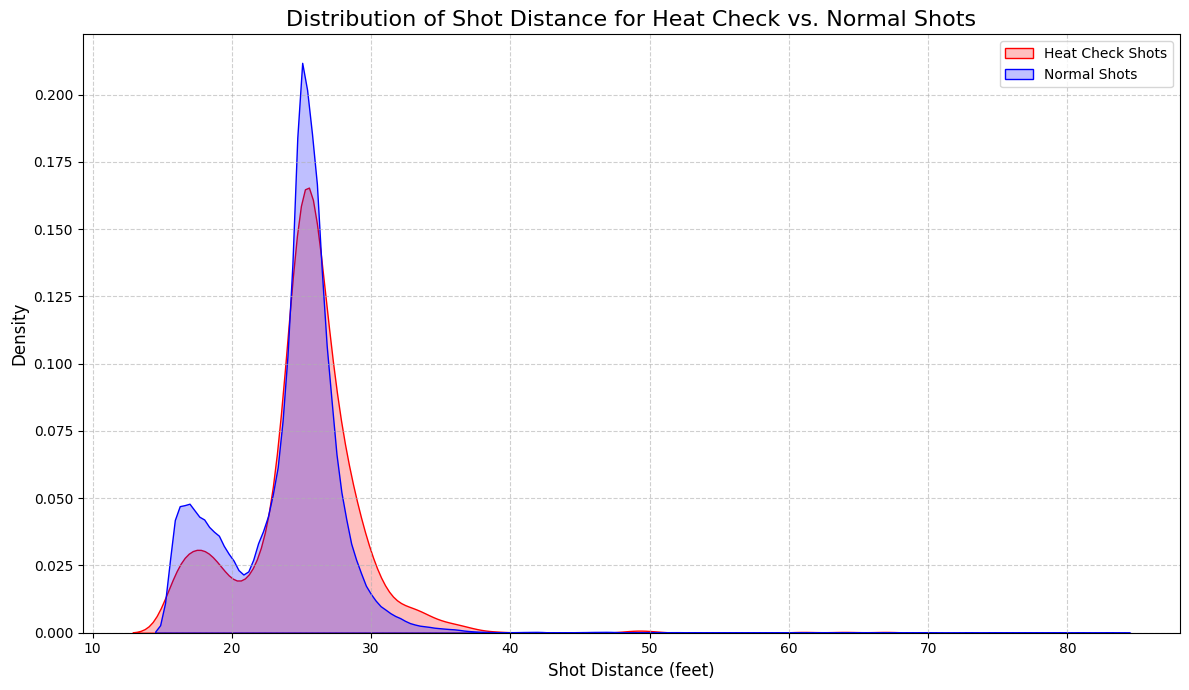

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 7))
ax = plt.gca()
sns.kdeplot(heat_checks['SHOT_DISTANCE'], color='red', label='Heat Check Shots', fill=True, ax=ax)
sns.kdeplot(regular_shots['SHOT_DISTANCE'], color='blue', label='Normal Shots', fill=True, ax=ax)
ax.set_xlabel('Shot Distance (feet)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Shot Distance for Heat Check vs. Normal Shots', fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.show()


## Shot Success Rate


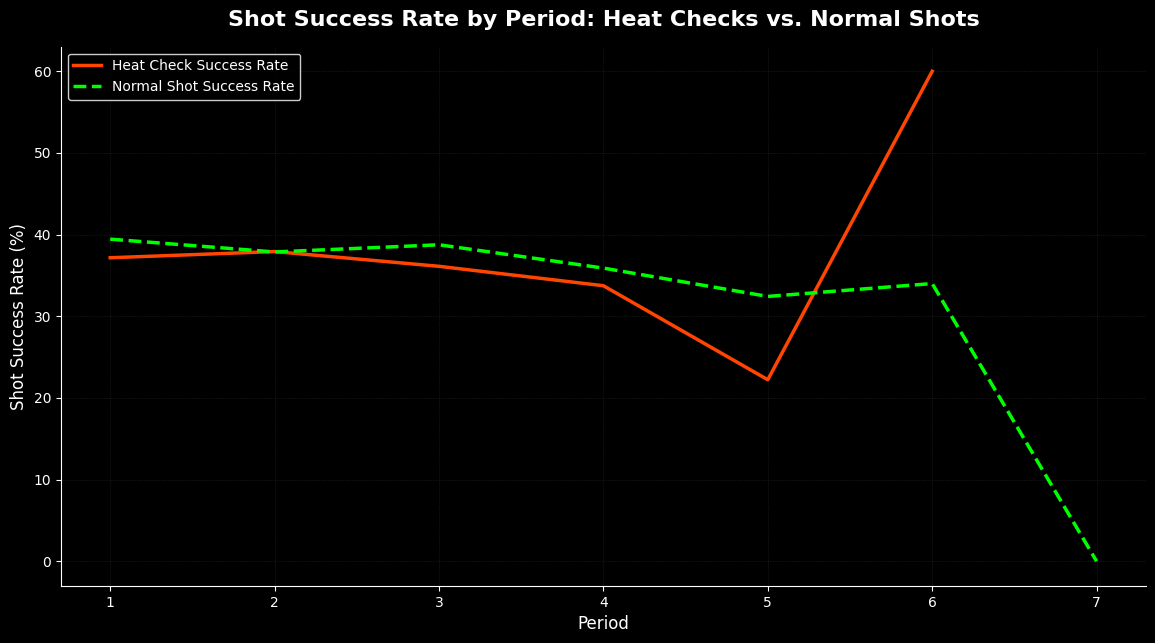

In [ ]:
hc_success_rate = heat_checks.groupby('PERIOD')['SHOT_MADE_FLAG'].mean().reset_index()
hc_success_rate['SHOT_MADE_FLAG'] = hc_success_rate['SHOT_MADE_FLAG'] * 100
reg_success_rate = regular_shots.groupby('PERIOD')['SHOT_MADE_FLAG'].mean().reset_index()
reg_success_rate['SHOT_MADE_FLAG'] = reg_success_rate['SHOT_MADE_FLAG'] * 100


plt.figure(figsize=(14, 7), facecolor='black')
ax = plt.gca()
style_dark_mode(ax)
ax.plot(hc_success_rate['PERIOD'], hc_success_rate['SHOT_MADE_FLAG'], color='#FF4500', label='Heat Check Success Rate', linewidth=2.5)
ax.plot(reg_success_rate['PERIOD'], reg_success_rate['SHOT_MADE_FLAG'], color='#00FF00', label='Normal Shot Success Rate', linestyle='--', linewidth=2.5)
ax.set_xlabel('Period', color='white', fontsize=12)
ax.set_ylabel('Shot Success Rate (%)', color='white', fontsize=12)
ax.set_title('Shot Success Rate by Period: Heat Checks vs. Normal Shots', color='white', fontsize=16, fontweight='bold', pad=15)
legend = ax.legend(facecolor='black', edgecolor='white', loc='best')
for text in legend.get_texts(): text.set_color("white")
max_period = int(max(hc_success_rate['PERIOD'].max(), reg_success_rate['PERIOD'].max()))
ax.set_xticks(range(1, max_period + 1))


plt.show()

## Shot Success by shotd made in row



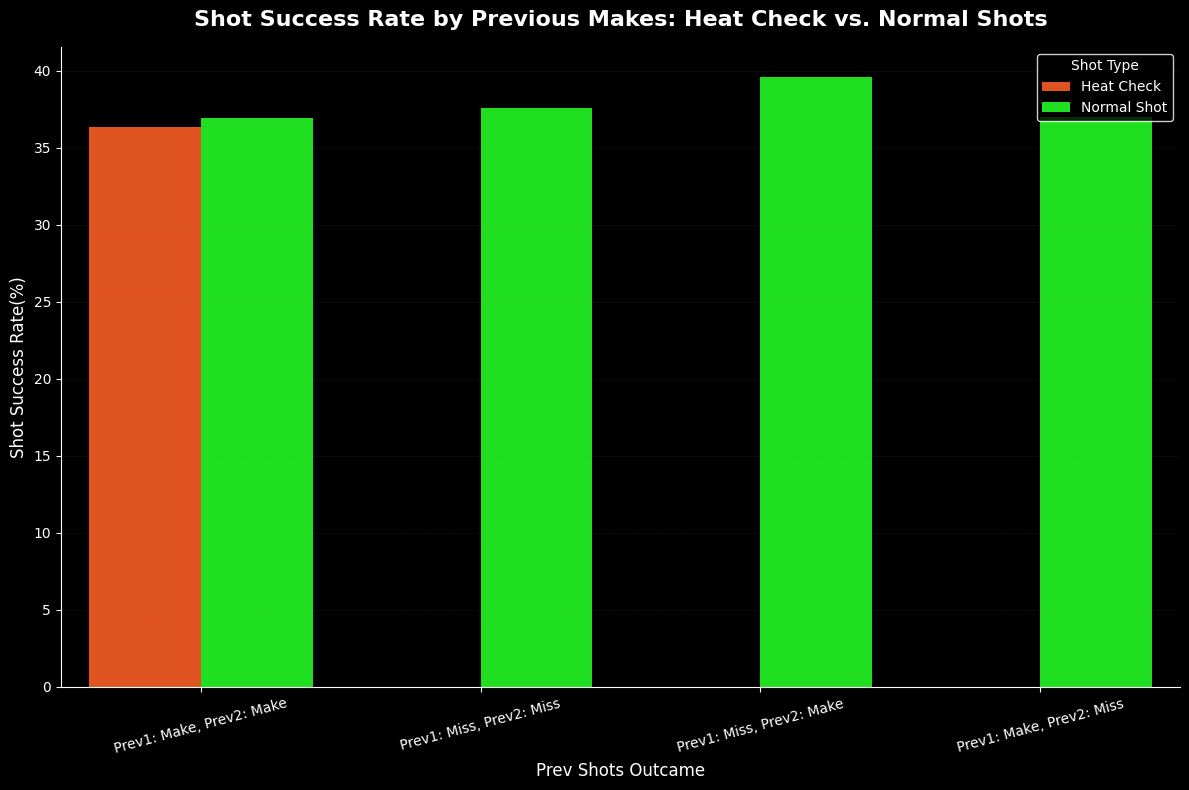

In [ ]:
success_rates_by_prev_makes = df.dropna(subset=['prev_1_make', 'prev_2_make']).groupby(['shot_type', 'prev_1_make', 'prev_2_make'])['SHOT_MADE_FLAG'].mean().reset_index()
success_rates_by_prev_makes['SHOT_MADE_FLAG'] = success_rates_by_prev_makes['SHOT_MADE_FLAG'] * 100
def get_prev_make_combination(row):
    prev1 = 'Make' if row['prev_1_make'] == 1 else 'Miss'
    prev2 = 'Make' if row['prev_2_make'] == 1 else 'Miss'
    return f'Prev1: {prev1}, Prev2: {prev2}'

success_rates_by_prev_makes['Prev_Makes_Combination'] = success_rates_by_prev_makes.apply(get_prev_make_combination, axis=1)
plt.figure(figsize=(12, 8), facecolor='black')
ax = plt.gca()
style_dark_mode(ax)
sns.barplot(x='Prev_Makes_Combination',y='SHOT_MADE_FLAG',hue='shot_type',data=success_rates_by_prev_makes,palette={'Heat Check': '#FF4500', 'Normal Shot': '#00FF00'},ax=ax)
ax.set_title('Shot Success Rate by Previous Makes: Heat Check vs. Normal Shots', color='white', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Prev Shots Outcame', color='white', fontsize=12)
ax.set_ylabel('Shot Success Rate(%)', color='white', fontsize=12)
legend = ax.legend(title='Shot Type', facecolor='black', edgecolor='white', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

###Heat  Check zones of the top3 players

In [ ]:
heat_check_counts = heat_checks['PLAYER_NAME'].value_counts()
top_3_players = heat_check_counts.head(3)

print("Top 3 Players with Most Heat Checks:")
print(top_3_players)

Top 3 Players with Most Heat Checks:
PLAYER_NAME
Luka Dončić      139
Stephen Curry    130
Zach LaVine      129
Name: count, dtype: int64


In [ ]:
top_3_player_names = top_3_players.index.tolist()
print("Top 3 Player Names:", top_3_player_names)

Top 3 Player Names: ['Luka Dončić', 'Stephen Curry', 'Zach LaVine']


In [ ]:
player_analysis_df = df[df['PLAYER_NAME'].isin(top_3_player_names)].copy()

player_efficiency = player_analysis_df.groupby(['PLAYER_NAME', 'shot_type'])['SHOT_MADE_FLAG'].mean().reset_index()
player_efficiency['SHOT_MADE_FLAG'] = player_efficiency['SHOT_MADE_FLAG'] * 100

print("Shooting Efficiency for Top 3 Players:")
print(player_efficiency)


Shooting Efficiency for Top 3 Players:
     PLAYER_NAME    shot_type  SHOT_MADE_FLAG
0    Luka Dončić   Heat Check       33.093525
1    Luka Dončić  Normal Shot       35.903840
2  Stephen Curry   Heat Check       32.307692
3  Stephen Curry  Normal Shot       41.133385
4    Zach LaVine   Heat Check       41.085271
5    Zach LaVine  Normal Shot       39.772265


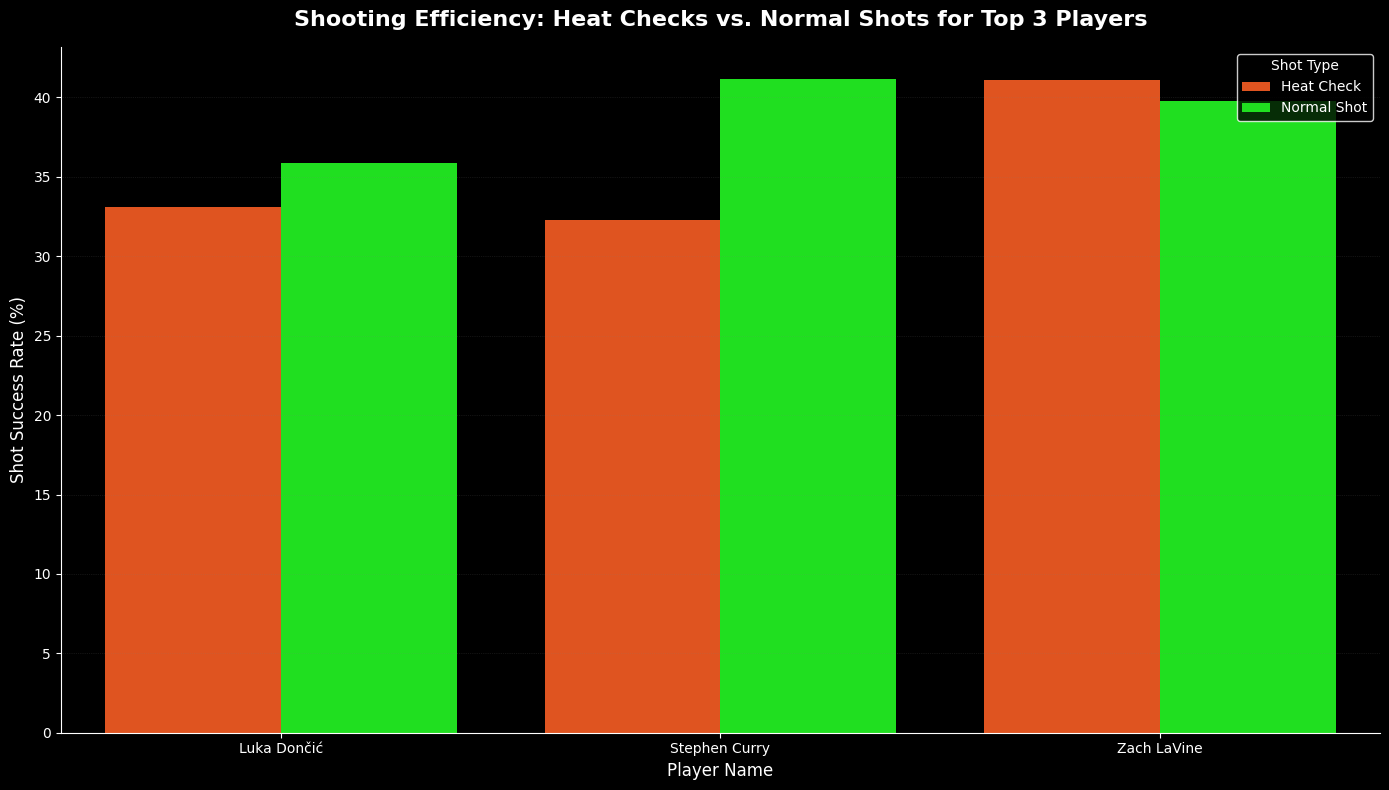

In [ ]:
plt.figure(figsize=(14, 8), facecolor='black')
ax = plt.gca()
style_dark_mode(ax)

sns.barplot(x='PLAYER_NAME', y='SHOT_MADE_FLAG', hue='shot_type', data=player_efficiency, palette={'Heat Check': '#FF4500', 'Normal Shot': '#00FF00'}, ax=ax)

ax.set_title('Shooting Efficiency: Heat Checks vs. Normal Shots for Top 3 Players', color='white', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Player Name', color='white', fontsize=12)
ax.set_ylabel('Shot Success Rate (%)', color='white', fontsize=12)

# Adjusting legend for dark mode
legend = ax.legend(title='Shot Type', facecolor='black', edgecolor='white', loc='upper right')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

plt.tight_layout()
plt.show()

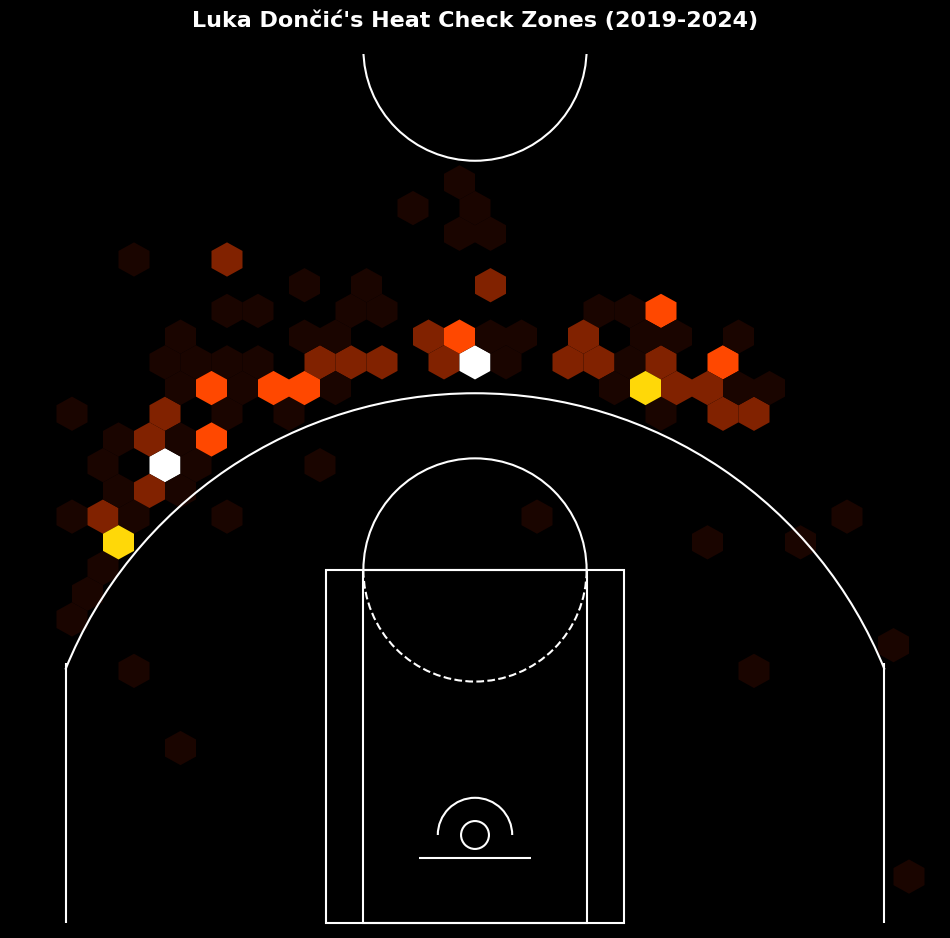

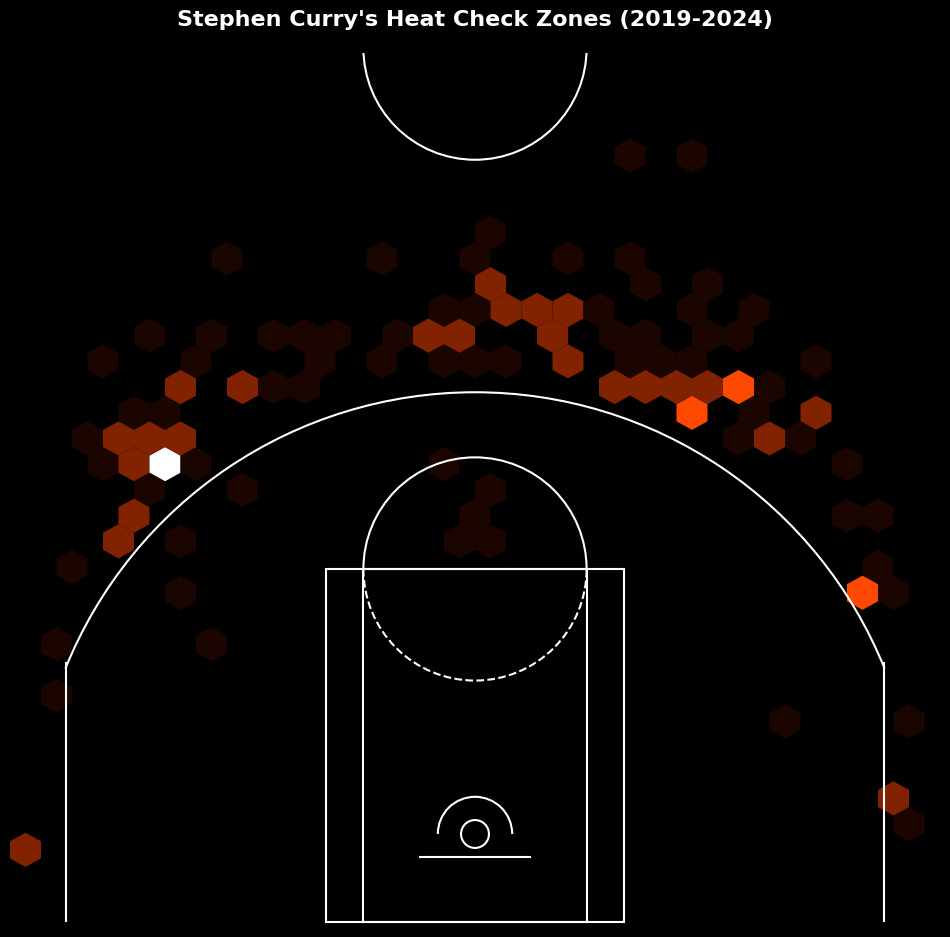

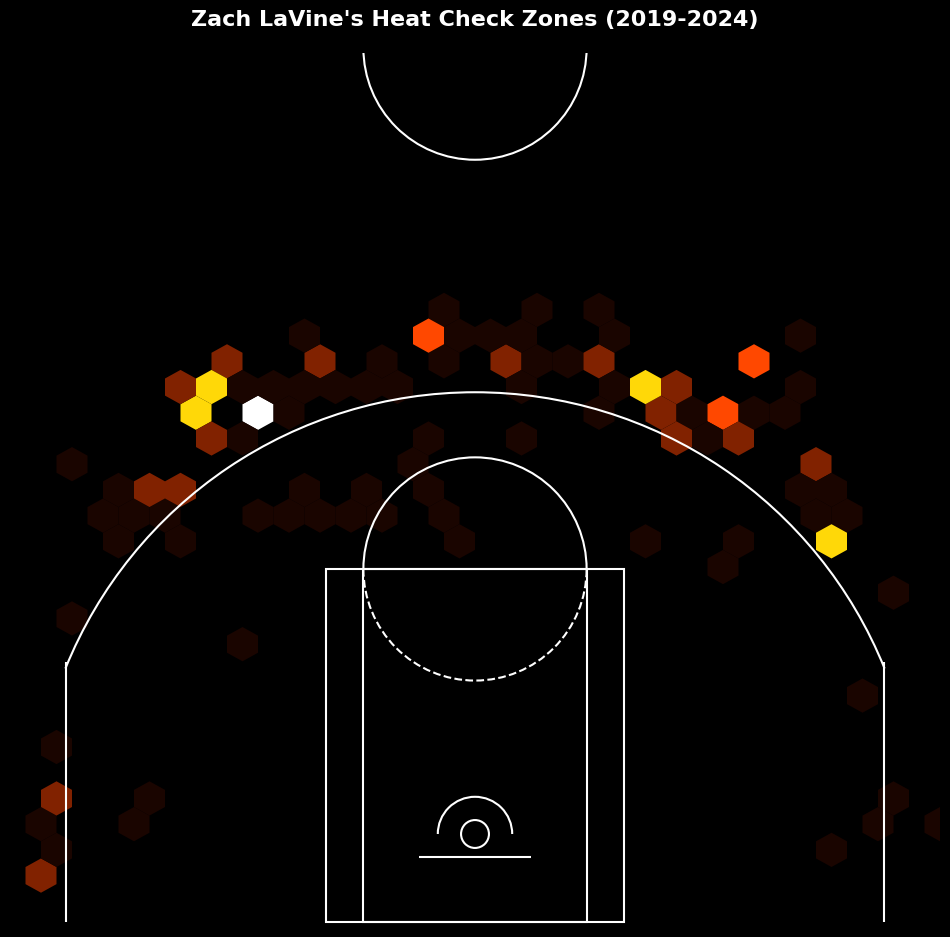

In [ ]:
for player_name in top_3_player_names:
    player_heat_checks = heat_checks[heat_checks['PLAYER_NAME'] == player_name].copy()

    plt.figure(figsize=(12, 12), facecolor='black')
    ax = plt.gca()
    ax.set_facecolor('black')
    colors = ['#1a0500', '#802200', '#FF4500', '#FFD700', '#FFFFFF']
    cmap = mcolors.LinearSegmentedColormap.from_list("black_to_neon", colors, N=100)

    ax.hexbin(
        player_heat_checks['X_feet'],
        player_heat_checks['Y_feet'],
        gridsize=30,
        cmap=cmap,
        mincnt=1,
        extent=(-25, 25, -5, 42),
        edgecolors='none',
        zorder=1
    )

    draw_nba_court(ax, color='white', lw=1.5)
    ax.set_aspect('equal')
    ax.set_xlim(-25, 25)
    ax.set_ylim(-5, 42)
    ax.axis('off')
    ax.set_title(f"{player_name}'s Heat Check Zones (2019-2024)",
                  color='white', fontsize=16, fontweight='bold', pad=20)

    plt.show()

##FEATURE ENGINEERING

In [ ]:
model_df_engineered = model_df.copy()

# Re-initialize the features list to avoid cumulative appending on re-execution
features = [
    'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
    'game_seconds_elapsed', 'PERIOD',
    'prev_1_make', 'prev_2_make',
    'is_heat_check' # This was added earlier in Ub69XE7kS_yH
]

model_df_engineered['SHOT_DISTANCE_x_IS_HEAT_CHECK'] = model_df_engineered['SHOT_DISTANCE'] * model_df_engineered['is_heat_check']
model_df_engineered['PERIOD_x_IS_HEAT_CHECK'] = model_df_engineered['PERIOD'] * model_df_engineered['is_heat_check']
model_df_engineered['SHOT_DISTANCE_SQ'] = model_df_engineered['SHOT_DISTANCE']**2
model_df_engineered['GAME_SECONDS_ELAPSED_SQ'] = model_df_engineered['game_seconds_elapsed']**2

new_engineered_features = ['SHOT_DISTANCE_x_IS_HEAT_CHECK','PERIOD_x_IS_HEAT_CHECK','SHOT_DISTANCE_SQ','GAME_SECONDS_ELAPSED_SQ']
features.extend(new_engineered_features)

print(f"Updated features list: {features}")

Updated features list: ['SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'game_seconds_elapsed', 'PERIOD', 'prev_1_make', 'prev_2_make', 'is_heat_check', 'SHOT_DISTANCE_x_IS_HEAT_CHECK', 'PERIOD_x_IS_HEAT_CHECK', 'SHOT_DISTANCE_SQ', 'GAME_SECONDS_ELAPSED_SQ']


##Modelling

In [ ]:
X_engineered = model_df_engineered[features]
y_engineered = model_df_engineered[target]

X_train_engineered, X_test_engineered, y_train_engineered, y_test_engineered = train_test_split(X_engineered, y_engineered, test_size=0.2, random_state=42)

xgb_model_engineered = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    random_state=42
)
xgb_model_engineered.fit(X_train_engineered, y_train_engineered)
y_pred_class_engineered = xgb_model_engineered.predict(X_test_engineered)
y_pred_proba_engineered = xgb_model_engineered.predict_proba(X_test_engineered)[:, 1]

accuracy_engineered = accuracy_score(y_test_engineered, y_pred_class_engineered)
roc_auc_engineered = roc_auc_score(y_test_engineered, y_pred_proba_engineered)

print("\n" + "="*40)
print("--- MODEL EVALUATION RESULTS (with engineered features) ---")
print("="*40)
print(f"Overall Accuracy: {accuracy_engineered * 100:.2f}%")
print(f"ROC-AUC Score:    {roc_auc_engineered:.3f}")
print("-" * 40)
print("Classification Report:")
print(classification_report(y_test_engineered, y_pred_class_engineered, target_names=['Missed (0)', 'Made (1)']))

print("\n" + "="*40)
print("--- FEATURE IMPORTANCE (with engineered features) ---")
print("="*40)
importance_df_engineered = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model_engineered.feature_importances_ * 100
}).sort_values(by='Importance', ascending=False)

print(importance_df_engineered.to_string(index=False))


--- MODEL EVALUATION RESULTS (with engineered features) ---
Overall Accuracy: 62.39%
ROC-AUC Score:    0.533
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

  Missed (0)       0.63      0.98      0.77      4134
    Made (1)       0.38      0.02      0.04      2446

    accuracy                           0.62      6580
   macro avg       0.51      0.50      0.40      6580
weighted avg       0.54      0.62      0.50      6580


--- FEATURE IMPORTANCE (with engineered features) ---
                      Feature  Importance
                SHOT_DISTANCE   15.024998
                       PERIOD   12.134453
                        LOC_Y   10.750830
         game_seconds_elapsed   10.379830
                is_heat_check    9.161064
                  prev_1_make    9.098159
                  prev_2_make    8.917852
                        LOC_X    8.826843
       PERIOD_x_IS_HEAT_CHECK    8.171045
SHOT_DISTANCE_x_IS_HEAT_

In [ ]:
features_to_remove = ['SHOT_DISTANCE_SQ', 'GAME_SECONDS_ELAPSED_SQ']
features = [f for f in features if f not in features_to_remove]
model_df_engineered = model_df_engineered.drop(columns=features_to_remove, errors='ignore')

print(f"Updated features list after removal: {features}")

Updated features list after removal: ['SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'game_seconds_elapsed', 'PERIOD', 'prev_1_make', 'prev_2_make', 'is_heat_check', 'SHOT_DISTANCE_x_IS_HEAT_CHECK', 'PERIOD_x_IS_HEAT_CHECK']


In [ ]:
print("Class distribution of SHOT_MADE_FLAG before handling imbalance:")
print(model_df_engineered[target].value_counts())

X_tuned = model_df_engineered[features]
y_tuned = model_df_engineered[target]

X_train_tuned, X_test_tuned, y_train_tuned, y_test_tuned = train_test_split(X_tuned, y_tuned, test_size=0.2, random_state=42, stratify=y_tuned)

print("\nClass distribution in y_train_tuned (before SMOTE):")
print(y_train_tuned.value_counts())
print("\nClass distribution in y_test_tuned:")
print(y_test_tuned.value_counts())

!pip install imblearn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tuned, y_train_tuned)

print("\nClass distribution in y_train_resampled (after SMOTE):")
print(y_train_resampled.value_counts())


Class distribution of SHOT_MADE_FLAG before handling imbalance:
SHOT_MADE_FLAG
0    20463
1    12434
Name: count, dtype: int64

Class distribution in y_train_tuned (before SMOTE):
SHOT_MADE_FLAG
0    16370
1     9947
Name: count, dtype: int64

Class distribution in y_test_tuned:
SHOT_MADE_FLAG
0    4093
1    2487
Name: count, dtype: int64

Class distribution in y_train_resampled (after SMOTE):
SHOT_MADE_FLAG
0    16370
1    16370
Name: count, dtype: int64


In [ ]:
print("Training XGBoost Model with resampled data...")
xgb_model_tuned = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    random_state=42
)
xgb_model_tuned.fit(X_train_resampled, y_train_resampled)

y_pred_class_tuned = xgb_model_tuned.predict(X_test_tuned)
y_pred_proba_tuned = xgb_model_tuned.predict_proba(X_test_tuned)[:, 1]

accuracy_tuned = accuracy_score(y_test_tuned, y_pred_class_tuned)
roc_auc_tuned = roc_auc_score(y_test_tuned, y_pred_proba_tuned)

print("\n" + "="*40)
print("--- MODEL EVALUATION RESULTS (with SMOTE and tuned features) ---")
print("="*40)
print(f"Overall Accuracy: {accuracy_tuned * 100:.2f}%")
print(f"ROC-AUC Score:    {roc_auc_tuned:.3f}")
print("-" * 40)
print("Classification Report:")
print(classification_report(y_test_tuned, y_pred_class_tuned, target_names=['Missed (0)', 'Made (1)']))

print("\n" + "="*40)
print("--- FEATURE IMPORTANCE (with SMOTE and tuned features) ---")
print("="*40)
importance_df_tuned = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model_tuned.feature_importances_ * 100
}).sort_values(by='Importance', ascending=False)

print(importance_df_tuned.to_string(index=False))


Training XGBoost Model with resampled data...

--- MODEL EVALUATION RESULTS (with SMOTE and tuned features) ---
Overall Accuracy: 61.08%
ROC-AUC Score:    0.537
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

  Missed (0)       0.63      0.91      0.74      4093
    Made (1)       0.44      0.11      0.18      2487

    accuracy                           0.61      6580
   macro avg       0.54      0.51      0.46      6580
weighted avg       0.56      0.61      0.53      6580


--- FEATURE IMPORTANCE (with SMOTE and tuned features) ---
                      Feature  Importance
                  prev_1_make   51.064682
                  prev_2_make   38.546310
                is_heat_check    2.081525
                SHOT_DISTANCE    1.932669
SHOT_DISTANCE_x_IS_HEAT_CHECK    1.228813
         game_seconds_elapsed    1.187860
                        LOC_Y    1.122439
                       PERIOD    1.015523
          

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("Training Logistic Regression Model with GridSearchCV...")

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

lr_model = LogisticRegression(random_state=42, max_iter=1000)

grid_search = GridSearchCV(estimator=lr_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='roc_auc',
                           n_jobs=-1,  # Use all available cores
                           verbose=1)

grid_search.fit(X_train_resampled, y_train_resampled)
print("\n" + "="*40)
print("--- GridSearchCV Best Parameters and Score ---")
print("="*40)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC Score: {grid_search.best_score_:.3f}")

best_lr_model = grid_search.best_estimator_
y_pred_class_lr = best_lr_model.predict(X_test_tuned)
y_pred_proba_lr = best_lr_model.predict_proba(X_test_tuned)[:, 1]

accuracy_lr = accuracy_score(y_test_tuned, y_pred_class_lr)
print("\n" + "="*40)
print("--- Logistic Regression Model Evaluation (with SMOTE and tuned features) ---")
print("="*40)
print(f"Overall Accuracy: {accuracy_lr * 100:.2f}%")

roc_auc_lr = roc_auc_score(y_test_tuned, y_pred_proba_lr)
print(f"ROC-AUC Score:    {roc_auc_lr:.3f}")
print("-" * 40)

print("Classification Report:")
print(classification_report(y_test_tuned, y_pred_class_lr, target_names=['Missed (0)', 'Made (1)']))


Training Logistic Regression Model with GridSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- GridSearchCV Best Parameters and Score ---
Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best ROC-AUC Score: 0.566

--- Logistic Regression Model Evaluation (with SMOTE and tuned features) ---
Overall Accuracy: 54.70%
ROC-AUC Score:    0.541
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

  Missed (0)       0.64      0.62      0.63      4093
    Made (1)       0.41      0.43      0.42      2487

    accuracy                           0.55      6580
   macro avg       0.52      0.52      0.52      6580
weighted avg       0.55      0.55      0.55      6580



In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest Classifier with GridSearchCV...")

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
rf_model = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(estimator=rf_model,
                              param_grid=param_grid_rf,
                              cv=5,
                              scoring='roc_auc',
                              n_jobs=-1,
                              verbose=1)
grid_search_rf.fit(X_train_resampled, y_train_resampled)

print("\n" + "="*40)
print("--- GridSearchCV Best Parameters and Score (Random Forest) ---")
print("="*40)
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best ROC-AUC Score: {grid_search_rf.best_score_:.3f}")

best_rf_model = grid_search_rf.best_estimator_
y_pred_class_rf = best_rf_model.predict(X_test_tuned)
y_pred_proba_rf = best_rf_model.predict_proba(X_test_tuned)[:, 1]

accuracy_rf = accuracy_score(y_test_tuned, y_pred_class_rf)
print("\n" + "="*40)
print("--- Random Forest Model Evaluation (with SMOTE and tuned features) ---")
print("="*40)
print(f"Overall Accuracy: {accuracy_rf * 100:.2f}%")

roc_auc_rf = roc_auc_score(y_test_tuned, y_pred_proba_rf)
print(f"ROC-AUC Score:    {roc_auc_rf:.3f}")
print("-" * 40)

print("Classification Report:")
print(classification_report(y_test_tuned, y_pred_class_rf, target_names=['Missed (0)', 'Made (1)']))

Training Random Forest Classifier with GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- GridSearchCV Best Parameters and Score (Random Forest) ---
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best ROC-AUC Score: 0.714

--- Random Forest Model Evaluation (with SMOTE and tuned features) ---
Overall Accuracy: 56.23%
ROC-AUC Score:    0.531
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

  Missed (0)       0.63      0.72      0.67      4093
    Made (1)       0.40      0.30      0.34      2487

    accuracy                           0.56      6580
   macro avg       0.51      0.51      0.51      6580
weighted avg       0.54      0.56      0.55      6580



In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Training XGBoost Model with GridSearchCV...")

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

grid_search_xgb = GridSearchCV(estimator=xgb_model,
                               param_grid=param_grid_xgb,
                               cv=5,
                               scoring='roc_auc',
                               n_jobs=-1,
                               verbose=1)
grid_search_xgb.fit(X_train_resampled, y_train_resampled)
print("\n" + "="*40)
print("--- GridSearchCV Best Parameters and Score (XGBoost) ---")
print("="*40)
print(f"Best Parameters: {grid_search_xgb.best_params_}")
print(f"Best ROC-AUC Score: {grid_search_xgb.best_score_:.3f}")
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_class_xgb_tuned = best_xgb_model.predict(X_test_tuned)
y_pred_proba_xgb_tuned = best_xgb_model.predict_proba(X_test_tuned)[:, 1]
accuracy_xgb_tuned = accuracy_score(y_test_tuned, y_pred_class_xgb_tuned)
print("\n" + "="*40)
print("--- XGBoost Model Evaluation (with SMOTE and tuned features) ---")
print("="*40)
print(f"Overall Accuracy: {accuracy_xgb_tuned * 100:.2f}%")
roc_auc_xgb_tuned = roc_auc_score(y_test_tuned, y_pred_proba_xgb_tuned)
print(f"ROC-AUC Score:    {roc_auc_xgb_tuned:.3f}")
print("-" * 40)
print("Classification Report:")
print(classification_report(y_test_tuned, y_pred_class_xgb_tuned, target_names=['Missed (0)', 'Made (1)']))
print("\n" + "="*40)
print("--- FEATURE IMPORTANCE (tuned XGBoost model) ---")
print("="*40)
importance_df_xgb_tuned = pd.DataFrame({
    'Feature': features,
    'Importance': best_xgb_model.feature_importances_ * 100
}).sort_values(by='Importance', ascending=False)

print(importance_df_xgb_tuned.to_string(index=False))


Training XGBoost Model with GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- GridSearchCV Best Parameters and Score (XGBoost) ---
Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best ROC-AUC Score: 0.689

--- XGBoost Model Evaluation (with SMOTE and tuned features) ---
Overall Accuracy: 57.55%
ROC-AUC Score:    0.528
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

  Missed (0)       0.63      0.76      0.69      4093
    Made (1)       0.41      0.27      0.32      2487

    accuracy                           0.58      6580
   macro avg       0.52      0.51      0.51      6580
weighted avg       0.55      0.58      0.55      6580


--- FEATURE IMPORTANCE (tuned XGBoost model) ---
                      Feature  Importance
                  prev_1_make   41.260540
                  prev_2_make   28.136969
                is_heat_check   10.324106
         